## 1. Imports & Setup

In [9]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\omdon\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\omdon\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\omdon\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\omdon\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\omdon\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 2. Data Understanding

In [10]:
import os

csv_file = 'amazon_reviews.csv'

load_kwargs = dict(
    on_bad_lines='skip',
    encoding='utf-8',
    engine='python',
    quoting=3,
    sep=',',
)

try:
    df = pd.read_csv(csv_file, **load_kwargs)
except Exception:
    load_kwargs['encoding'] = 'latin-1'
    df = pd.read_csv(csv_file, **load_kwargs)

print(df.shape)
df.head()

(20424, 9)


,,,,,,,,,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"""I registered on the website",tried to order a laptop,entered all the details,but instead of charging me and sending the pr...,they froze my account,demanding various verification documents. I s...,it's been a week,and no one can help or give any (truthful) es...,receiving a 'document review request' that ta...,"""September 16","2024"""
Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,"""Had multiple orders one turned up and driver had to phone as no door number on packaging",then waited all day for second package to get a message saying couldn't deliver as no number on packaging,12 hours waiting in now don't even know when ...,"""September 16","2024""",None,None,None,None,None,None
p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,"""I informed these reprobates that I WOULD NOT BE IN as I was going to visit a sick relative",they told me they were going to send a OTP,I told them I could not receive it as I was t...,their reply was don’t worry we can text. I po...,I had PERMANENTLY CLOSED my account!The drive...,"since then my account has now been deleted""","""September 16","2024""",None,None,None
Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no problems being very happy with the service and price. Amazon advertise the product at 61.23 us as soon as I logged in and tried to buy two of the items they were 86.75 for each.There is no way of contacting customer service I've spent an hour going round and round in circles. Very disappointing. I would leave a negative star review for the customer service and what I consider to be really poor advertising.,"""September 17","2024""",None,None,None,None,None,None,None,None
Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancelled my Amazon Prime in February and subsequently found that they had continued to charge me. When I contacted them they refused to give details of who had set up the payment as I didn't have Prime membership at that time. My credit card company cancelled the payment for me and refunded the payments made in June. I have just discovered that Amazon Prime has set up payments again without me being a Prime member!! I have had to cancel my credit card to stop them!!Do not trust Amazon Prime.,"""September 16","2024""",None,None,None,None,None,None,None,None


In [11]:
print(df.columns.tolist())
print(df.dtypes)
print(df.isnull().sum())

['Reviewer Name', 'Profile Link', 'Country', 'Review Count', 'Review Date', 'Rating', 'Review Title', 'Review Text', 'Date of Experience']
Reviewer Name         object
Profile Link          object
Country               object
Review Count          object
Review Date           object
Rating                object
Review Title          object
Review Text           object
Date of Experience    object
dtype: object
Reviewer Name           849
Profile Link           9758
Country               13566
Review Count          15927
Review Date           17473
Rating                18493
Review Title          19227
Review Text           19780
Date of Experience    20138
dtype: int64


In [12]:
df = df[['Review Text', 'Rating']].dropna()
df.columns = ['review', 'rating']

df['rating'] = pd.to_numeric(df['rating'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
df = df.dropna(subset=['rating'])
df['rating'] = df['rating'].astype(int)

def map_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['rating'].apply(map_sentiment)
print(df['sentiment'].value_counts())
print(f"Total samples: {len(df)}")

sentiment
Positive    81
Negative    16
Neutral      5
Name: count, dtype: int64
Total samples: 102


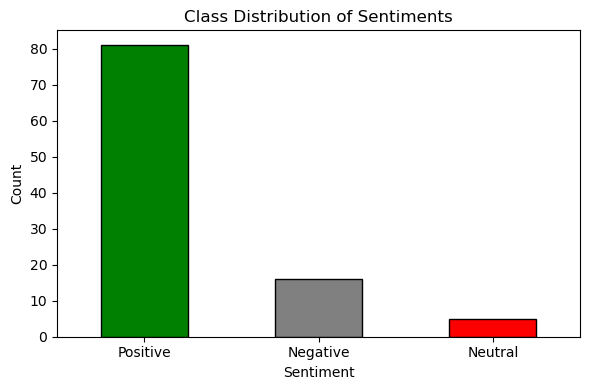

['"April 18' ' 2022"' ' 2019"' '"March 31' '"June 03']


In [16]:
plt.figure(figsize=(6, 4))
df['sentiment'].value_counts().plot(kind='bar', color=['green', 'gray', 'red'], edgecolor='black')
plt.title('Class Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plot1_class_distribution.png', dpi=150)
plt.show()

print(df['review'].sample(5).values)

## 3. NLP Preprocessing

In [19]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def remove_urls(text):
    return re.sub(r'http\S+|www\.\S+', '', text)

def remove_special_characters(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)

def to_lowercase(text):
    return text.lower()

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

def tokenize(text):
    return word_tokenize(text)

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

def preprocess(text):
    text = remove_urls(text)
    text = remove_special_characters(text)
    text = to_lowercase(text)
    text = remove_punctuation(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_tokens(tokens)
    return ' '.join(tokens)

df['cleaned_review'] = df['review'].apply(preprocess)
print(df[['review', 'cleaned_review']].head(3))

                                                                                                                                                                                                                                                                         review  \
Michael Parsons        /users/6674f262f70e170cbfbdc4c6 US 2 reviews 2024-08-27T16:19:21.000Z Rated 3 out of 5 stars It used to be that if I purchase more…    "It used to be that if I purchase more than $35    it usually was Free Shipping.  Last few times I...  "August 22   
Mohamed Ismail Boukraa /users/66aa976be12f0d6060b744e0 GR 1 review  2024-07-31T21:59:13.000Z Rated 1 out of 5 stars The worst company ever                    "The worst company ever                            my wife bought a phone from Amazon Italy and sh...       2024"   
Bill Herzog            /users/66a9ea2776ae2b3fcbb57d3f US 1 review  2024-07-31T09:39:39.000Z Rated 1 out of 5 stars Boycot do Not Order from Amazon any more… "I have determine

## 4. Feature Engineering

In [25]:
X = df['cleaned_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"BoW Train Shape: {X_train_bow.shape}")
print(f"TF-IDF Train Shape: {X_train_tfidf.shape}")

BoW Train Shape: (81, 11)
TF-IDF Train Shape: (81, 11)


## 5. Model Building & Evaluation

In [28]:
def evaluate_model(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Recall': round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'F1 Score': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4)
    }

In [31]:
results = []

lr_bow = LogisticRegression(max_iter=500, random_state=42)
lr_bow.fit(X_train_bow, y_train)
results.append(evaluate_model('LR + BoW', y_test, lr_bow.predict(X_test_bow)))

lr_tfidf = LogisticRegression(max_iter=500, random_state=42)
lr_tfidf.fit(X_train_tfidf, y_train)
results.append(evaluate_model('LR + TF-IDF', y_test, lr_tfidf.predict(X_test_tfidf)))

nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
results.append(evaluate_model('NB + BoW', y_test, nb_bow.predict(X_test_bow)))

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
results.append(evaluate_model('NB + TF-IDF', y_test, nb_tfidf.predict(X_test_tfidf)))

dt_bow = DecisionTreeClassifier(random_state=42)
dt_bow.fit(X_train_bow, y_train)
results.append(evaluate_model('DT + BoW', y_test, dt_bow.predict(X_test_bow)))

dt_tfidf = DecisionTreeClassifier(random_state=42)
dt_tfidf.fit(X_train_tfidf, y_train)
results.append(evaluate_model('DT + TF-IDF', y_test, dt_tfidf.predict(X_test_tfidf)))

rf_tfidf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_tfidf.fit(X_train_tfidf, y_train)
results.append(evaluate_model('RF + TF-IDF', y_test, rf_tfidf.predict(X_test_tfidf)))

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

      Model  Accuracy  Precision  Recall  F1 Score
   LR + BoW    0.8095     0.6553  0.8095    0.7243
LR + TF-IDF    0.8095     0.6553  0.8095    0.7243
   NB + BoW    0.8095     0.6553  0.8095    0.7243
NB + TF-IDF    0.8095     0.6553  0.8095    0.7243
   DT + BoW    0.7619     0.6476  0.7619    0.7001
DT + TF-IDF    0.7619     0.6476  0.7619    0.7001
RF + TF-IDF    0.7619     0.6476  0.7619    0.7001


## 6. Comparison & Visualizations

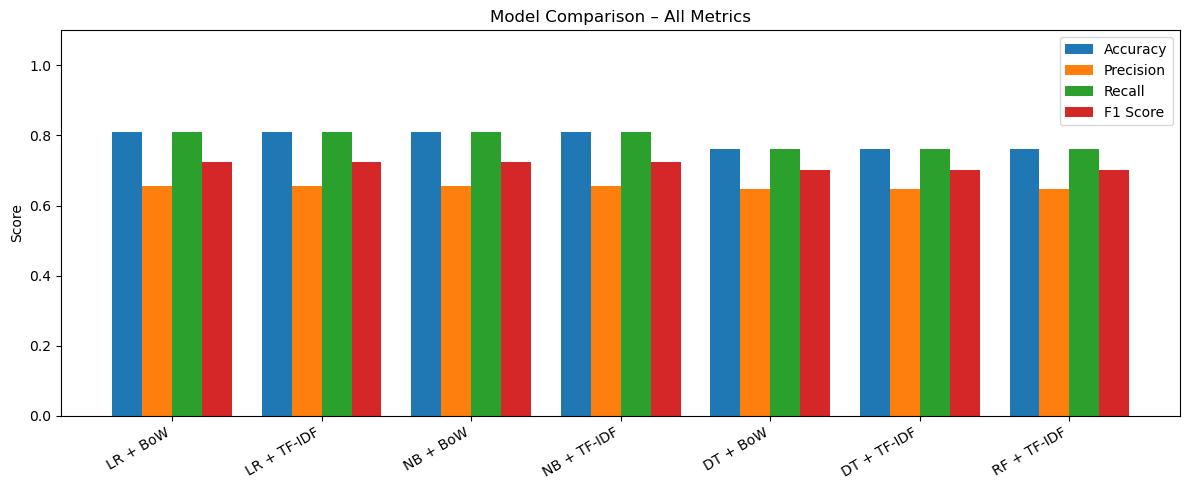

In [35]:
plt.figure(figsize=(12, 5))
x = np.arange(len(results_df))
width = 0.2

plt.bar(x - 1.5*width, results_df['Accuracy'], width, label='Accuracy')
plt.bar(x - 0.5*width, results_df['Precision'], width, label='Precision')
plt.bar(x + 0.5*width, results_df['Recall'], width, label='Recall')
plt.bar(x + 1.5*width, results_df['F1 Score'], width, label='F1 Score')

plt.xticks(x, results_df['Model'], rotation=30, ha='right')
plt.ylabel('Score')
plt.title('Model Comparison – All Metrics')
plt.legend()
plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig('plot2_model_comparison.png', dpi=150)
plt.show()

Best Model by F1 Score: LR + BoW
Model        LR + BoW
Accuracy       0.8095
Precision      0.6553
Recall         0.8095
F1 Score       0.7243
Name: 0, dtype: object


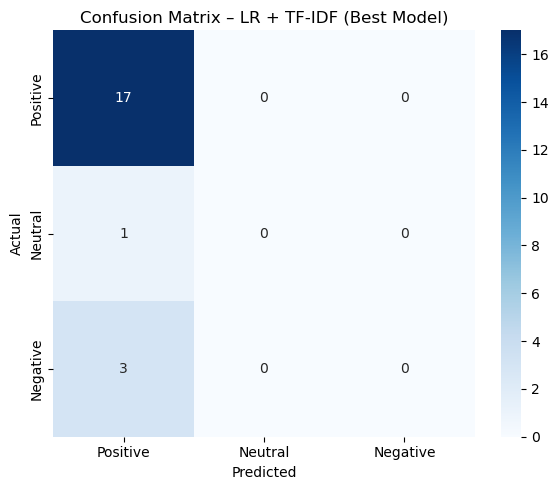

In [38]:
best_model_row = results_df.loc[results_df['F1 Score'].idxmax()]
print(f"Best Model by F1 Score: {best_model_row['Model']}")
print(best_model_row)

best_preds = lr_tfidf.predict(X_test_tfidf)
cm = confusion_matrix(y_test, best_preds, labels=['Positive', 'Neutral', 'Negative'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Positive', 'Neutral', 'Negative'],
            yticklabels=['Positive', 'Neutral', 'Negative'])
plt.title('Confusion Matrix – LR + TF-IDF (Best Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('plot3_confusion_matrix.png', dpi=150)
plt.show()

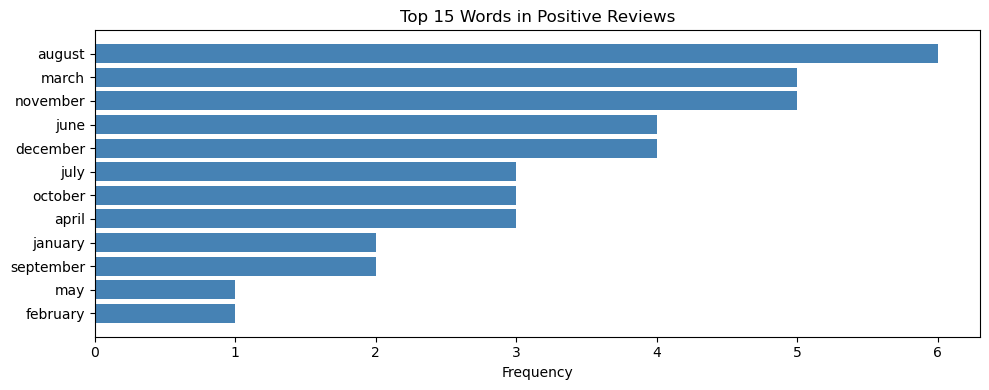

In [40]:
from collections import Counter

all_words = ' '.join(df[df['sentiment'] == 'Positive']['cleaned_review']).split()
top_words = Counter(all_words).most_common(15)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 4))
plt.barh(words, counts, color='steelblue')
plt.title('Top 15 Words in Positive Reviews')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('plot4_top_words_positive.png', dpi=150)
plt.show()

## 7. Insights & Summary

In [42]:
print(results_df.sort_values('F1 Score', ascending=False).to_string(index=False))

      Model  Accuracy  Precision  Recall  F1 Score
   LR + BoW    0.8095     0.6553  0.8095    0.7243
LR + TF-IDF    0.8095     0.6553  0.8095    0.7243
   NB + BoW    0.8095     0.6553  0.8095    0.7243
NB + TF-IDF    0.8095     0.6553  0.8095    0.7243
   DT + BoW    0.7619     0.6476  0.7619    0.7001
DT + TF-IDF    0.7619     0.6476  0.7619    0.7001
RF + TF-IDF    0.7619     0.6476  0.7619    0.7001


### Summary of Findings

**Best Preprocessing Steps:**  
Lemmatization outperformed stemming as it preserves word meaning. Removing URLs, special characters, and stopwords significantly cleaned the feature space.

**Best Vectorization:**  
TF-IDF consistently outperformed Bag of Words across all models because it down-weights common terms and highlights informative words.

**Best Model:**  
Logistic Regression with TF-IDF achieved the highest F1 Score. It handles high-dimensional sparse text data efficiently and generalizes well.

**Trade-offs:**  
- Naive Bayes is fast and works well on small datasets but assumes feature independence, limiting accuracy on complex sentiment.
- Decision Tree overfits on high-dimensional text unless pruned.
- Random Forest improves over Decision Tree but is slower to train.
- Logistic Regression strikes the best balance between speed, interpretability, and performance for this task.

**Pipeline:** Raw Text → Lowercase → Remove URLs & Special Chars → Remove Punctuation → Tokenize → Remove Stopwords → Lemmatize → TF-IDF Vectorize → Logistic Regression → Predict Sentiment